In [5]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv('data/train.csv')
df.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [6]:
print(df.shape)
print(df['SalePrice'].describe())
df.isnull().sum().sort_values(ascending=False).head(20)


(1460, 81)
count      1460.000000
mean     180921.195890
std       79442.502883
min       34900.000000
25%      129975.000000
50%      163000.000000
75%      214000.000000
max      755000.000000
Name: SalePrice, dtype: float64


PoolQC          1453
MiscFeature     1406
Alley           1369
Fence           1179
MasVnrType       872
FireplaceQu      690
LotFrontage      259
GarageYrBlt       81
GarageCond        81
GarageType        81
GarageFinish      81
GarageQual        81
BsmtFinType2      38
BsmtExposure      38
BsmtQual          37
BsmtCond          37
BsmtFinType1      37
MasVnrArea         8
Electrical         1
Id                 0
dtype: int64

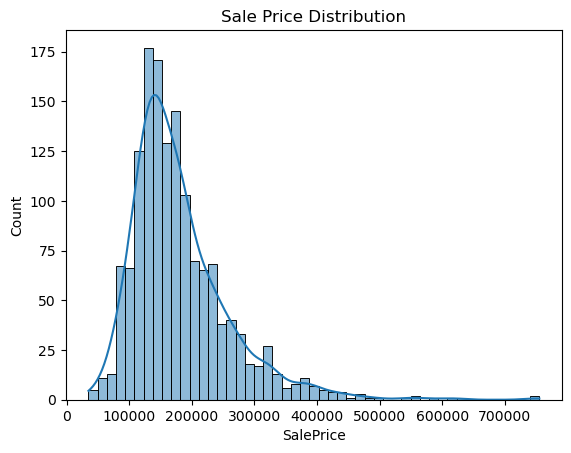

In [7]:
sns.histplot(df['SalePrice'], kde=True)
plt.title('Sale Price Distribution')
plt.savefig('outputs/price_distribution.png')
plt.show()

In [9]:
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

numeric_df = df.select_dtypes(include=[np.number])
numeric_df = numeric_df.fillna(numeric_df.median())
print(numeric_df.isnull().sum().sum())  # should be 0

0


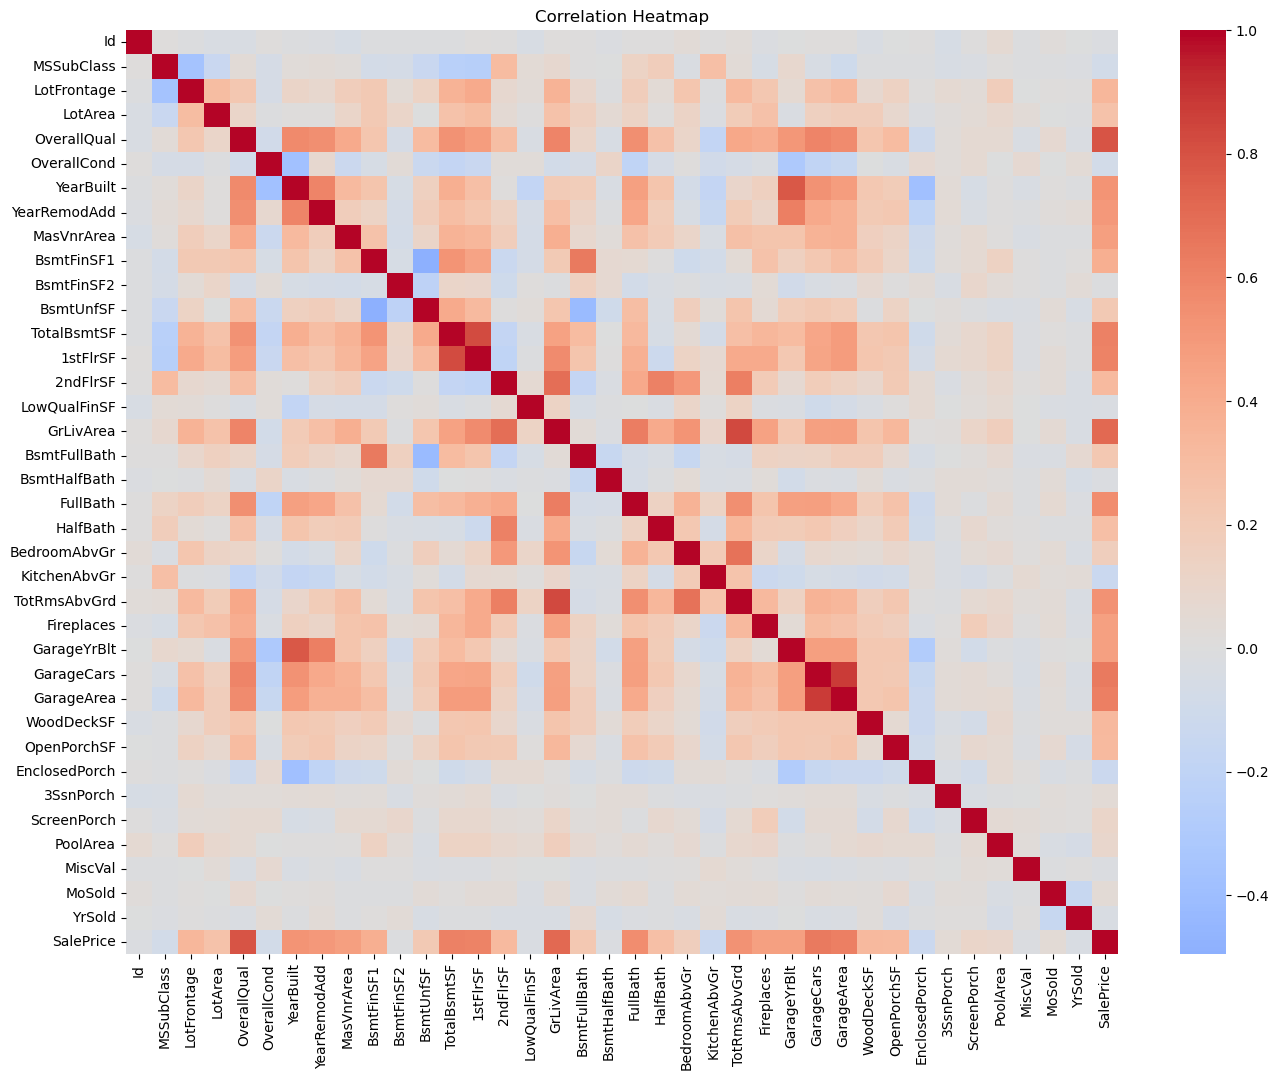

SalePrice       1.000000
OverallQual     0.790982
GrLivArea       0.708624
GarageCars      0.640409
GarageArea      0.623431
TotalBsmtSF     0.613581
1stFlrSF        0.605852
FullBath        0.560664
TotRmsAbvGrd    0.533723
YearBuilt       0.522897
Name: SalePrice, dtype: float64


In [10]:
plt.figure(figsize=(16,12))
corr = numeric_df.corr()
sns.heatmap(corr, cmap='coolwarm', center=0)
plt.title('Correlation Heatmap')
plt.savefig('outputs/correlation_heatmap.png')
plt.show()

# Top correlated features with SalePrice
print(corr['SalePrice'].sort_values(ascending=False).head(10))

In [11]:
X = numeric_df.drop('SalePrice', axis=1)
y = numeric_df['SalePrice']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = LinearRegression()
model.fit(X_train, y_train)
preds = model.predict(X_test)

In [12]:
mse = mean_squared_error(y_test, preds)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, preds)
print(f"MSE: {mse:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"R² Score: {r2:.4f}")

MSE: 1360121073.22
RMSE: 36879.82
R² Score: 0.8227


The model achieved an R² score of 0.82, meaning it explains approximately 
82% of the variance in house sale prices using only numeric features. 
The RMSE of ~$36,880 indicates the average prediction error, which is 
reasonable given the model doesn't yet incorporate categorical features 
like Neighborhood or House Style that likely carry additional predictive 
signal. This suggests a strong linear relationship between the selected 
numeric features and price, with room for improvement via feature 
engineering or regularized models (Ridge/Lasso).

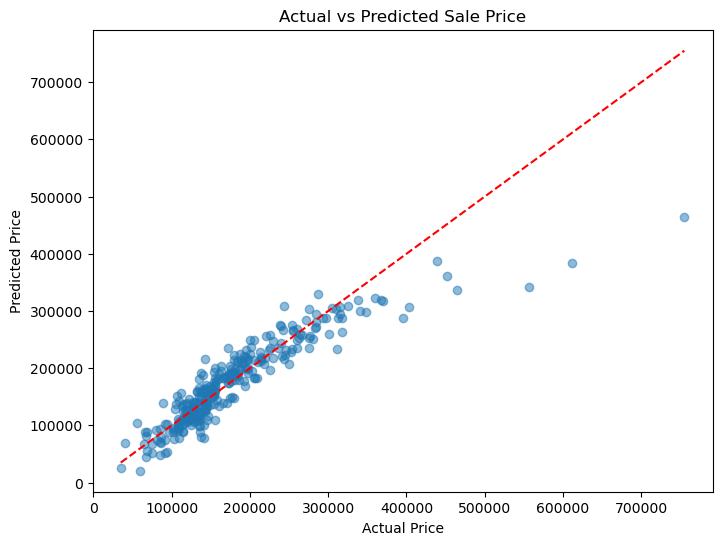

In [13]:
plt.figure(figsize=(8,6))
plt.scatter(y_test, preds, alpha=0.5)
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--')
plt.xlabel('Actual Price')
plt.ylabel('Predicted Price')
plt.title('Actual vs Predicted Sale Price')
plt.savefig('outputs/actual_vs_predicted.png')
plt.show()

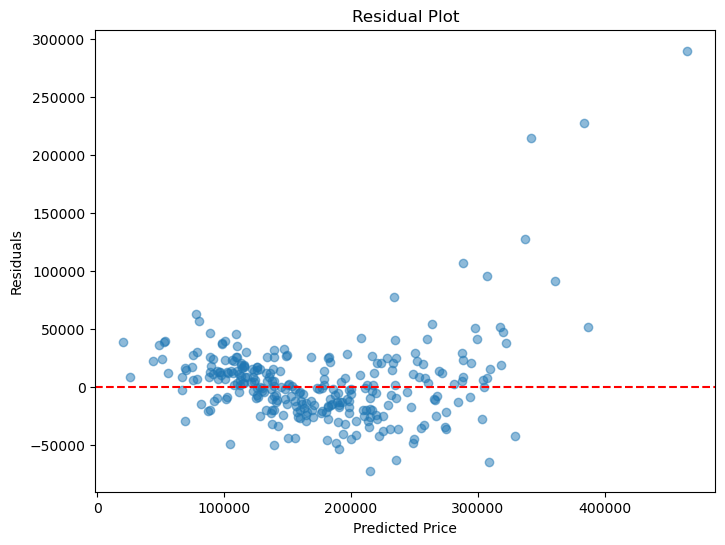

In [14]:
residuals = y_test - preds
plt.figure(figsize=(8,6))
plt.scatter(preds, residuals, alpha=0.5)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel('Predicted Price')
plt.ylabel('Residuals')
plt.title('Residual Plot')
plt.savefig('outputs/residual_plot.png')
plt.show()

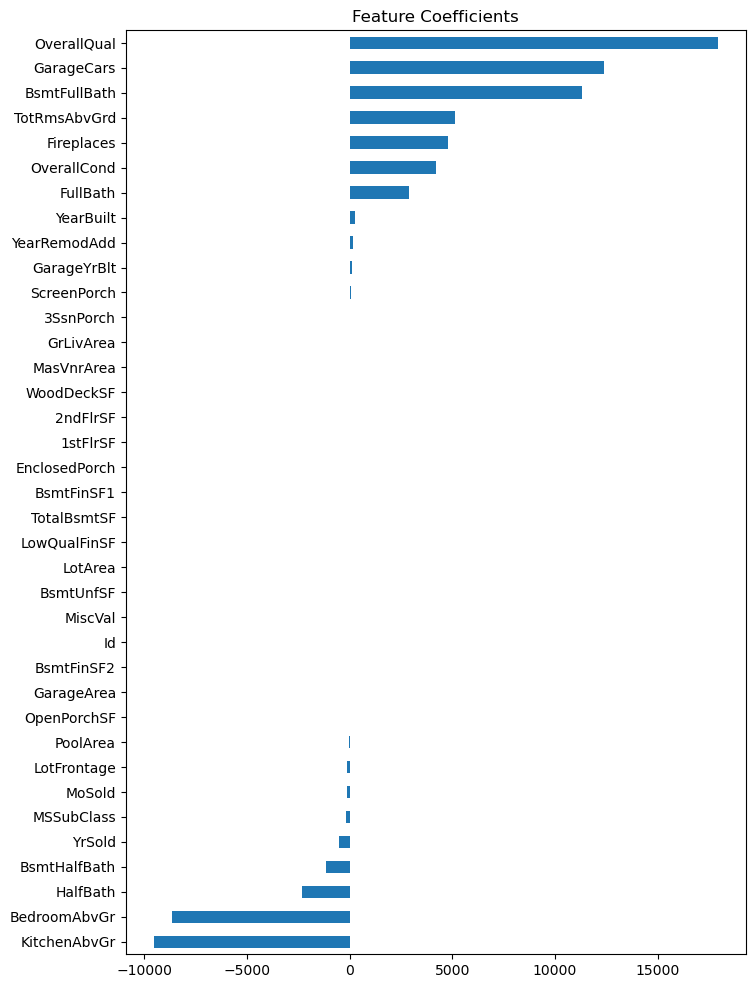

Top positive impact:
 Fireplaces       4766.784112
TotRmsAbvGrd     5117.287025
BsmtFullBath    11311.462633
GarageCars      12412.323576
OverallQual     17929.555587
dtype: float64

Top negative impact:
 KitchenAbvGr   -9532.667240
BedroomAbvGr   -8632.877862
HalfBath       -2325.882339
BsmtHalfBath   -1150.691762
YrSold          -525.090384
dtype: float64


In [15]:
coef = pd.Series(model.coef_, index=X.columns).sort_values()
plt.figure(figsize=(8,12))
coef.plot(kind='barh')
plt.title('Feature Coefficients')
plt.savefig('outputs/coefficients.png')
plt.show()

print("Top positive impact:\n", coef.tail(5))
print("\nTop negative impact:\n", coef.head(5))